# Insurance Claim Analysis: MDSA Capstone Project
**Author:** Tejaswin Amara  
**Course:** Mathematics for Data Science and Analytics (CO1–CO6)  
**University:** KLH University (Bachupally Campus)

## Project Overview
This project analyzes medical insurance charges to identify key risk factors driving claims. We apply a systematic statistical and machine learning approach across 6 Course Outcomes (CO1–CO6).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## CO1: Data Understanding & Preprocessing
We load the dataset, check for missing values, remove duplicates, and detect outliers using the IQR method.

In [2]:
# Load dataset (Assuming ../data/insurance.csv is in the same directory)
try:
    df = pd.read_csv('../data/insurance.csv')
except FileNotFoundError:
    # Creating a sample structure if file not found for demonstration
    print("File not found. Please ensure '../data/insurance.csv' is present.")

print(f"Dataset Shape: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum()}")

# Duplicate Removal
duplicates = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicates Removed: {duplicates}")

# Outlier Detection (IQR Method)
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))]
    return len(outliers)

for col in ['age', 'bmi', 'children', 'charges']:
    print(f"{col} outliers: {detect_outliers(df, col)}")

Dataset Shape: (1338, 7)
Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates Removed: 1
age outliers: 0
bmi outliers: 9
children outliers: 0
charges outliers: 139


## CO2: Descriptive Statistics
Analysis of central tendency, dispersion, and distribution shape for medical charges.

Mean: 13279.12
Median: 9386.16
Variance: 146660811.01
Skewness: 1.5154
Kurtosis: 1.6042


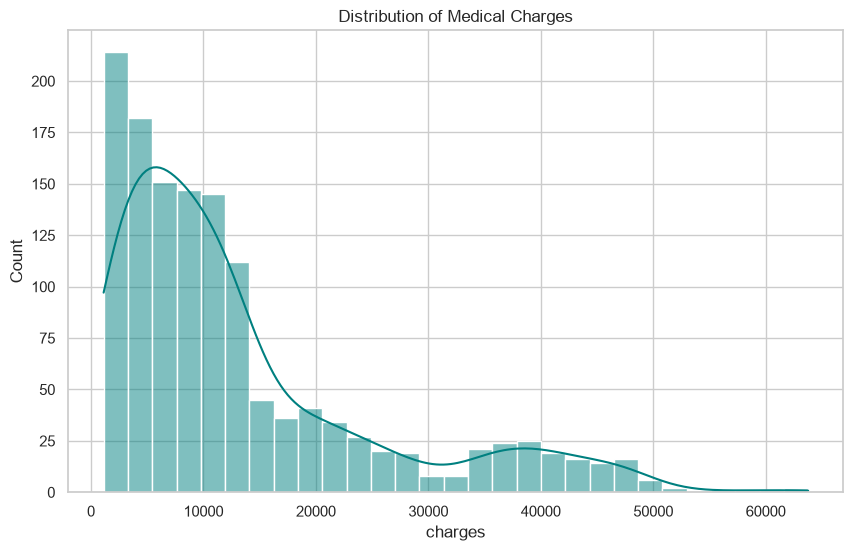

In [3]:
charges = df['charges']
print(f"Mean: {charges.mean():.2f}")
print(f"Median: {charges.median():.2f}")
print(f"Variance: {charges.var():.2f}")
print(f"Skewness: {charges.skew():.4f}")
print(f"Kurtosis: {charges.kurt():.4f}")

sns.histplot(charges, kde=True, color='teal')
plt.title('Distribution of Medical Charges')
plt.show()

## CO3: Probability & Distributions
Applying Bayes' Theorem and exploring statistical distributions.

In [4]:
# High Charge Event (Charges > Q3)
Q3 = charges.quantile(0.75)
df['high_charge'] = df['charges'] > Q3

p_high = df['high_charge'].mean()
p_smoker = (df['smoker'] == 'yes').mean()
p_high_given_smoker = df[df['smoker'] == 'yes']['high_charge'].mean()

# Bayes' Theorem: P(Smoker|High) = [P(High|Smoker) * P(Smoker)] / P(High)
p_smoker_given_high = (p_high_given_smoker * p_smoker) / p_high
print(f"P(Smoker | High Charge): {p_smoker_given_high:.4f}")

P(Smoker | High Charge): 0.7605


## CO4: Statistical Inference
Hypothesis testing (t-test) between smokers and non-smokers.

In [5]:
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smokers, non_smokers)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Reject Null Hypothesis: Significant difference exists between groups.")

T-Statistic: 46.6448
P-Value: 1.4067e-282
Reject Null Hypothesis: Significant difference exists between groups.


## CO5: Correlation & Simple Regression
Analyzing the relationship between Age and Charges.

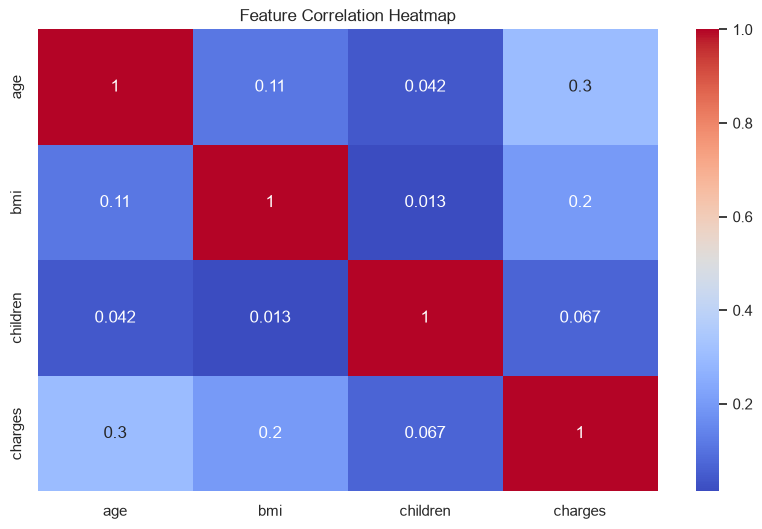

Equation: Charges = 257.23 * Age + 3190.02
R^2 Score: 0.0890


In [6]:
correlation = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Simple Linear Regression: Age vs Charges
X = df[['age']]
y = df['charges']
model_simple = LinearRegression().fit(X, y)
print(f"Equation: Charges = {model_simple.coef_[0]:.2f} * Age + {model_simple.intercept_:.2f}")
print(f"R^2 Score: {model_simple.score(X, y):.4f}")

## CO6: Multiple Linear Regression
Building a comprehensive model to predict charges using all key features.

MSE: 35914551.48
RMSE: 5992.88
R2 Score: 0.8046


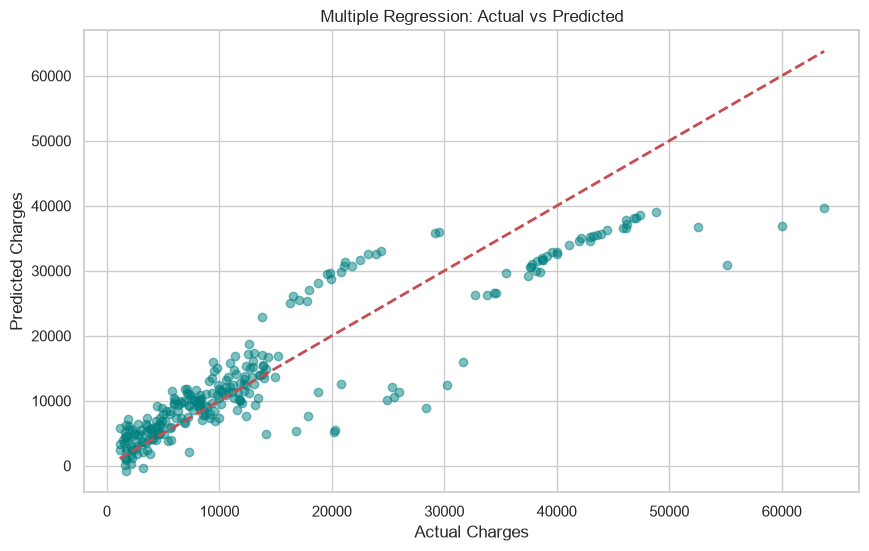

In [7]:
# Preprocessing for Multiple Regression
df_model = pd.get_dummies(df[['age', 'bmi', 'children', 'smoker', 'charges']], drop_first=True)

X_multi = df_model.drop('charges', axis=1)
y_multi = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression().fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Actual vs Predicted Plot
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Multiple Regression: Actual vs Predicted')
plt.show()